   label  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
0      3     107     118     127     134     139     143     146     150   
1      6     155     157     156     156     156     157     156     158   
2      2     187     188     188     187     187     186     187     188   
3      2     211     211     212     212     211     210     211     210   
4     13     164     167     170     172     176     179     180     184   

   pixel9  ...  pixel775  pixel776  pixel777  pixel778  pixel779  pixel780  \
0     153  ...       207       207       207       207       206       206   
1     158  ...        69       149       128        87        94       163   
2     187  ...       202       201       200       199       198       199   
3     210  ...       235       234       233       231       230       226   
4     185  ...        92       105       105       108       133       163   

   pixel781  pixel782  pixel783  pixel784  
0       206       204       20

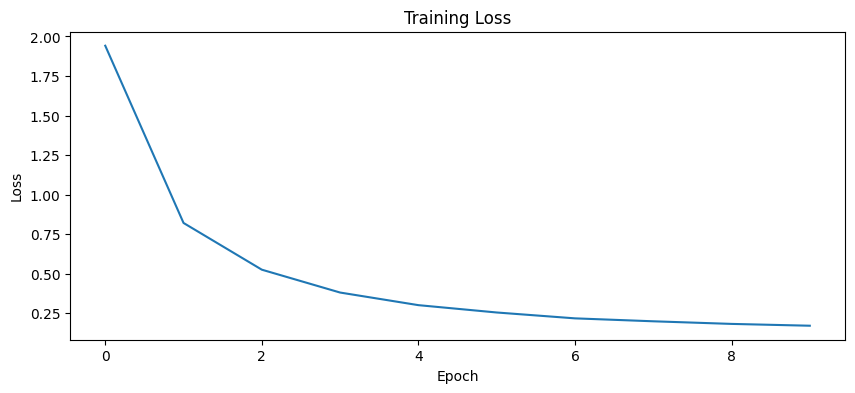

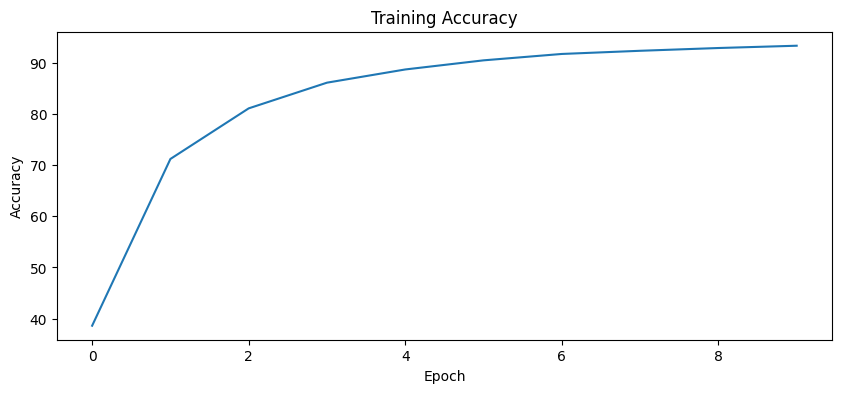

Test Accuracy: 92.39%


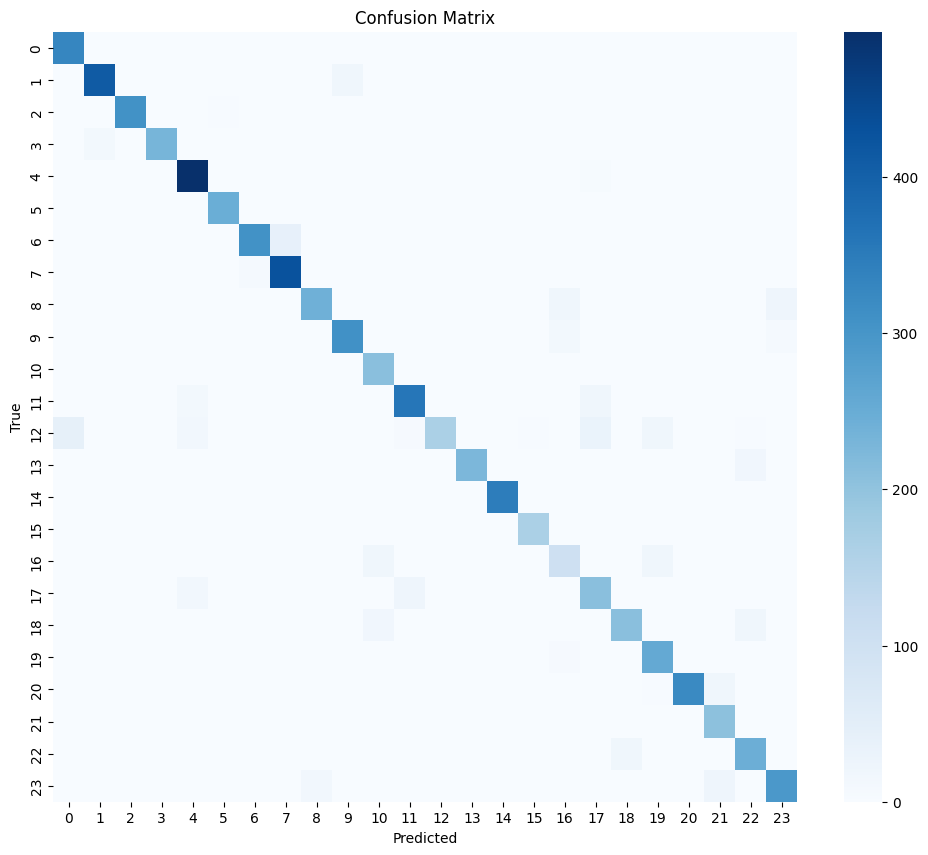

              precision    recall  f1-score   support

           0       0.88      1.00      0.94       331
           1       0.97      0.95      0.96       432
           2       1.00      0.99      1.00       310
           3       1.00      0.95      0.97       245
           4       0.92      0.99      0.95       498
           5       0.99      1.00      1.00       247
           6       0.97      0.88      0.92       348
           7       0.91      0.98      0.95       436
           8       0.94      0.84      0.89       288
          10       0.93      0.94      0.93       331
          11       0.84      1.00      0.91       209
          12       0.93      0.91      0.92       394
          13       0.99      0.57      0.72       291
          14       1.00      0.92      0.96       246
          15       1.00      1.00      1.00       347
          16       0.99      1.00      0.99       164
          17       0.72      0.72      0.72       144
          18       0.78    

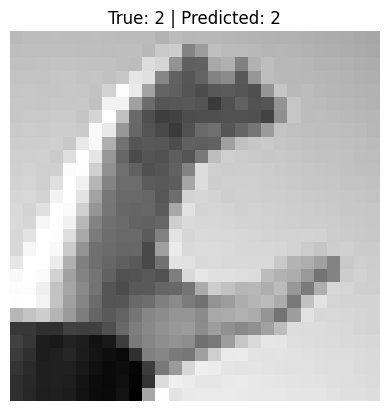

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)

# =========================================================
# 2. LOAD DATASET
# =========================================================

train_df = pd.read_csv("sign_mnist_train.csv")
test_df = pd.read_csv("sign_mnist_test.csv")

print(train_df.head())

# =========================================================
# 3. PREPROCESSING
# =========================================================

X_train = train_df.drop("label", axis=1).values
y_train = train_df["label"].values

X_test = test_df.drop("label", axis=1).values
y_test = test_df["label"].values

# normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

# reshape images
X_train = X_train.reshape(-1, 1, 28, 28)
X_test = X_test.reshape(-1, 1, 28, 28)

print(X_train.shape)

# =========================================================
# 4. CONVERT TO TENSORS
# =========================================================

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# =========================================================
# 5. DATASETS + DATALOADERS
# =========================================================

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Test batches:", len(test_loader))

# =========================================================
# 6. CNN MODEL
# =========================================================

class CNNBaseline(nn.Module):

    def __init__(self):

        super().__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)

        )

        self.fc = nn.Sequential(

            nn.Flatten(),

            nn.Linear(64 * 7 * 7, 128),

            nn.ReLU(),

            nn.Dropout(0.5),

            nn.Linear(128, 25)

        )

    def forward(self, x):

        x = self.conv(x)

        x = self.fc(x)

        return x

# =========================================================
# 7. MODEL
# =========================================================

model = CNNBaseline()

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

# =========================================================
# 8. TRAINING
# =========================================================

train_losses = []
train_accuracies = []

epochs = 10

for epoch in range(epochs):

    model.train()

    running_loss = 0.0

    correct = 0

    total = 0

    for images, labels in train_loader:

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)

    epoch_acc = 100 * correct / total

    train_losses.append(epoch_loss)

    train_accuracies.append(epoch_acc)

    print(f"Epoch {epoch+1}/{epochs}")

    print(f"Loss: {epoch_loss:.4f}")

    print(f"Accuracy: {epoch_acc:.2f}%")

# =========================================================
# 9. LEARNING CURVES
# =========================================================

plt.figure(figsize=(10,4))

plt.plot(train_losses)

plt.title("Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.show()

plt.figure(figsize=(10,4))

plt.plot(train_accuracies)

plt.title("Training Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.show()

# =========================================================
# 10. EVALUATION
# =========================================================

model.eval()

all_preds = []

all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.numpy())

        all_labels.extend(labels.numpy())

# =========================================================
# 11. TEST ACCURACY
# =========================================================

acc = accuracy_score(all_labels, all_preds)

print(f"Test Accuracy: {acc*100:.2f}%")

# =========================================================
# 12. CONFUSION MATRIX
# =========================================================

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(12,10))

sns.heatmap(cm, annot=False, cmap="Blues")

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("True")

plt.show()

# =========================================================
# 13. CLASSIFICATION REPORT
# =========================================================

print(classification_report(all_labels, all_preds))

# =========================================================
# 14. SAVE MODEL
# =========================================================

torch.save(model.state_dict(), "model_final.pth")

print("Model saved successfully!")

# =========================================================
# 15. TEST SINGLE IMAGE
# =========================================================

import random

sample, label = test_dataset[random.randint(0, len(test_dataset)-1)]

sample_input = sample.unsqueeze(0)

model.eval()

with torch.no_grad():

    output = model(sample_input)

    prediction = torch.argmax(output, 1).item()

plt.imshow(sample.squeeze(), cmap='gray')

plt.title(f"True: {label} | Predicted: {prediction}")

plt.axis("off")

plt.show()